In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, ConfusionMatrixDisplay

print("All libraries imported successfully!")

All libraries imported successfully!


In [3]:
# Note: Synthetic dataset created for POC purposes.
# Production implementation would use real clinical corpora 
# such as MIMIC-III or i2b2 datasets.
# Medical text dataset - 4 categories
data = {
    "text": [
        # Diagnosis
        "Patient presents with Type 2 diabetes mellitus and hypertension.",
        "Diagnosed with community-acquired pneumonia based on chest X-ray findings.",
        "Patient has a history of chronic obstructive pulmonary disease (COPD).",
        "Assessment reveals acute myocardial infarction requiring immediate intervention.",
        "Patient diagnosed with major depressive disorder and generalized anxiety.",
        "Clinical findings consistent with urinary tract infection.",
        "Patient presents with hypothyroidism confirmed by TSH levels.",
        "Diagnosis of rheumatoid arthritis based on joint inflammation and RF levels.",
        "Patient shows symptoms consistent with acute appendicitis.",
        "Confirmed diagnosis of chronic kidney disease stage 3.",

        # Prescription
        "Take Metformin 500mg twice daily with meals for blood sugar control.",
        "Prescribed Lisinopril 10mg once daily for blood pressure management.",
        "Administer Amoxicillin 250mg every 8 hours for 7 days.",
        "Patient to take Atorvastatin 20mg at bedtime for cholesterol.",
        "Prescribe Salbutamol inhaler, 2 puffs every 4-6 hours as needed.",
        "Take Omeprazole 20mg once daily before breakfast for acid reflux.",
        "Prescribed Sertraline 50mg daily for depression management.",
        "Administer Insulin Glargine 10 units subcutaneously at bedtime.",
        "Take Ibuprofen 400mg three times daily after meals for pain relief.",
        "Prescribed Amlodipine 5mg once daily for hypertension.",

        # Lab Report
        "Blood glucose level: 182 mg/dL. HbA1c: 8.1%. Fasting insulin: elevated.",
        "Complete blood count shows WBC 11,500/uL, RBC 4.2 million/uL, Hemoglobin 13.5 g/dL.",
        "Serum creatinine: 1.8 mg/dL. BUN: 24 mg/dL. eGFR: 42 mL/min.",
        "Thyroid function test: TSH 7.2 mIU/L, Free T4 0.7 ng/dL.",
        "Urine culture positive for E. coli, colony count >100,000 CFU/mL.",
        "Lipid panel: Total cholesterol 245 mg/dL, LDL 160 mg/dL, HDL 38 mg/dL.",
        "Liver function test: ALT 65 U/L, AST 58 U/L, Bilirubin 1.2 mg/dL.",
        "Chest X-ray shows consolidation in right lower lobe consistent with pneumonia.",
        "ECG reveals ST-segment elevation in leads II, III and aVF.",
        "Rheumatoid factor: 85 IU/mL. Anti-CCP antibodies: positive.",

        # Discharge Summary
        "Patient was admitted for 4 days and discharged in stable condition after treatment.",
        "Discharged with instructions to follow up with primary care physician in 2 weeks.",
        "Patient underwent appendectomy and was discharged on postoperative day 3.",
        "Following cardiac catheterization, patient discharged with dual antiplatelet therapy.",
        "Patient admitted with acute exacerbation of COPD, stabilized and discharged home.",
        "Discharge medications include Metformin, Lisinopril and Atorvastatin.",
        "Patient educated on wound care and discharged with outpatient physiotherapy referral.",
        "Admitted for pneumonia treatment, completed IV antibiotics, discharged on oral therapy.",
        "Patient recovered well post-surgery and was discharged with follow-up in 1 week.",
        "Discharge diagnosis: acute UTI. Patient discharged after 48 hours of IV antibiotics.",
    ],
    "label": ["Diagnosis"] * 10 + ["Prescription"] * 10 + ["Lab Report"] * 10 + ["Discharge Summary"] * 10
}

df = pd.DataFrame(data)
print(f"Dataset created: {len(df)} samples")
print(df["label"].value_counts())

Dataset created: 40 samples
label
Diagnosis            10
Prescription         10
Lab Report           10
Discharge Summary    10
Name: count, dtype: int64


In [4]:
# Split data
X_train, X_test, y_train, y_test = train_test_split(
    df["text"], df["label"], test_size=0.2, random_state=42
)

# Build pipeline - TF-IDF + Naive Bayes
model = Pipeline([
    ("tfidf", TfidfVectorizer()),
    ("nb", MultinomialNB())
])

# Train
model.fit(X_train, y_train)

print(f"Training samples: {len(X_train)}")
print(f"Testing samples: {len(X_test)}")
print("Model trained successfully!")

Training samples: 32
Testing samples: 8
Model trained successfully!


Accuracy: 75.00%

Classification Report:
                   precision    recall  f1-score   support

        Diagnosis       0.00      0.00      0.00         1
Discharge Summary       0.50      1.00      0.67         1
       Lab Report       1.00      0.50      0.67         2
     Prescription       1.00      1.00      1.00         4

         accuracy                           0.75         8
        macro avg       0.62      0.62      0.58         8
     weighted avg       0.81      0.75      0.75         8



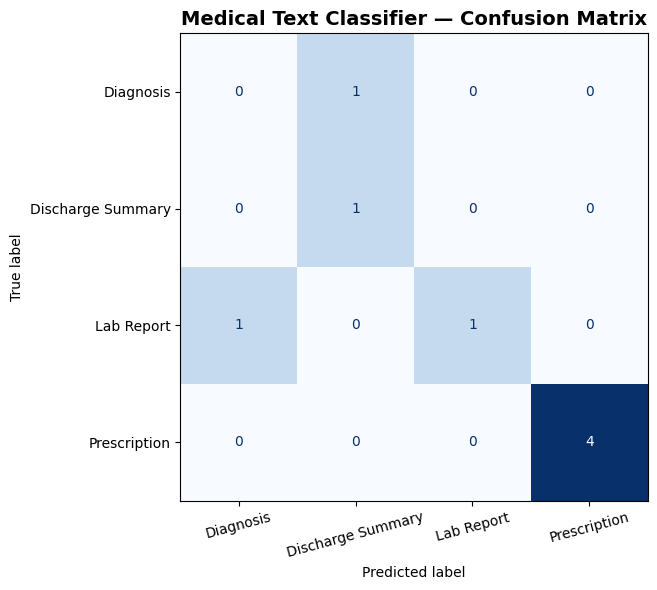

Confusion matrix saved!


In [5]:
# Predictions
pred = model.predict(X_test)

# Accuracy
print(f"Accuracy: {accuracy_score(y_test, pred):.2%}\n")

# Classification Report
print("Classification Report:")
print(classification_report(y_test, pred))

# Confusion Matrix
cm = confusion_matrix(y_test, pred, labels=model.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)

fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(ax=ax, cmap="Blues", colorbar=False)
plt.title("Medical Text Classifier — Confusion Matrix", fontsize=14, fontweight="bold")
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150)
plt.show()

print("Confusion matrix saved!")

In [6]:
import re

def extract_entities(text):
    entities = {
        "Symptoms": [],
        "Medications": [],
        "Dosages": [],
        "Lab Values": [],
        "Diagnoses": []
    }
    
    # Medications (common patterns)
    med_pattern = r'\b(Metformin|Lisinopril|Amoxicillin|Atorvastatin|Salbutamol|Omeprazole|Sertraline|Insulin|Ibuprofen|Amlodipine)\b'
    entities["Medications"] = re.findall(med_pattern, text, re.IGNORECASE)
    
    # Dosages (e.g. 500mg, 10 units)
    dosage_pattern = r'\b\d+\s*(?:mg|mcg|units?|mL|g)\b'
    entities["Dosages"] = re.findall(dosage_pattern, text, re.IGNORECASE)
    
    # Lab values (e.g. 126 mg/dL, 7.2%)
    lab_pattern = r'\b\d+\.?\d*\s*(?:mg/dL|mIU/L|U/L|g/dL|%|IU/mL|CFU/mL|mmol/L)\b'
    entities["Lab Values"] = re.findall(lab_pattern, text, re.IGNORECASE)
    
    # Symptoms
    symptom_pattern = r'\b(chest pain|fever|cough|fatigue|nausea|vomiting|headache|shortness of breath|dizziness|inflammation)\b'
    entities["Symptoms"] = re.findall(symptom_pattern, text, re.IGNORECASE)
    
    # Diagnoses
    diag_pattern = r'\b(diabetes|hypertension|pneumonia|COPD|appendicitis|arthritis|hypothyroidism|depression|anxiety|infection)\b'
    entities["Diagnoses"] = re.findall(diag_pattern, text, re.IGNORECASE)
    
    return {k: list(set(v)) for k, v in entities.items() if v}

# Test on a sample note
sample_note = """
Patient presents with Type 2 diabetes and hypertension. 
Prescribed Metformin 500mg twice daily and Lisinopril 10mg once daily.
Blood glucose: 182 mg/dL. HbA1c: 8.1%.
Patient discharged in stable condition after 3 days.
"""

print("=" * 50)
print("CLINICAL NOTE:")
print(sample_note)
print("=" * 50)
print("EXTRACTED ENTITIES:")
entities = extract_entities(sample_note)
for entity_type, values in entities.items():
    print(f"  {entity_type}: {', '.join(values)}")
print("=" * 50)

CLINICAL NOTE:

Patient presents with Type 2 diabetes and hypertension. 
Prescribed Metformin 500mg twice daily and Lisinopril 10mg once daily.
Blood glucose: 182 mg/dL. HbA1c: 8.1%.
Patient discharged in stable condition after 3 days.

EXTRACTED ENTITIES:
  Medications: Lisinopril, Metformin
  Dosages: 182 mg, 10mg, 500mg
  Lab Values: 182 mg/dL
  Diagnoses: diabetes, hypertension
